# Miami Property Crime and Florida Storm Activity Analysis

This notebook documents the analytical workflow used to examine **monthly Miami property-crime activity** alongside **statewide Florida storm-event frequency** during calendar year 2024.

The project emphasizes data extraction, cleaning, feature selection, analyst-defined classification, monthly aggregation, exploratory visualization, and Pearson correlation analysis.

## Analytical Question

**Do increases in Florida storm-event activity correspond with higher levels of Miami property crime?**

The analysis is exploratory. It evaluates whether the two monthly series move together and whether the observed linear relationship is statistically significant.

## Data Availability and Portfolio Reproducibility

The original crime and storm-event datasets were supplied through university coursework and are **not redistributed** in this repository because no explicit redistribution license was provided.

The original analysis queried two MySQL tables:

- `mpdcrimedata`
- `stormevents2024`

For portfolio demonstration, the notebook preserves the original extraction, cleaning, subsetting, and aggregation workflow but does not expose database credentials or raw course data.

When the original database is unavailable, the notebook uses the **12-row monthly aggregate produced by the original workflow** so the exploratory visualizations and statistical results can still be reproduced.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ALPHA = 0.05

# Leave False for the public portfolio version.
# Set to True only in an authorized environment containing the original course database.
USE_MYSQL_SOURCE = False

## 1. Original Data Extraction Workflow

The original project connected to MySQL and loaded the full crime and storm-event tables. Credentials have been removed from the portfolio version.

If the authorized source database is available, connection details can be supplied through environment variables rather than hard-coded into the notebook.

In [2]:
if USE_MYSQL_SOURCE:
    import mysql.connector

    cnx = mysql.connector.connect(
        user=os.environ["DAT375_DB_USER"],
        password=os.environ["DAT375_DB_PASSWORD"],
        host=os.environ.get("DAT375_DB_HOST", "127.0.0.1"),
        port=os.environ.get("DAT375_DB_PORT", "3306"),
        database=os.environ.get("DAT375_DB_NAME", "dat375"),
    )

    crime_df = pd.read_sql("SELECT * FROM mpdcrimedata", cnx)
    storm_df = pd.read_sql("SELECT * FROM stormevents2024", cnx)

    print(f"Crime records loaded: {len(crime_df):,}")
    print(f"Storm records loaded: {len(storm_df):,}")
else:
    print("Portfolio mode: raw course data are not distributed; using the derived monthly summary below.")

Portfolio mode: raw course data are not distributed; using the derived monthly summary below.


## 2. Analytical Decisions

### Defining Property Crime

The crime dataset did not contain a predefined property-crime flag. The original analysis reviewed the `IncidentType` values and selected records containing:

- burglary
- larceny
- stolen vehicle
- vandalism
- arson

This classification required analyst judgment and is therefore documented as a reproducibility limitation.

### Geographic Scope

The crime records represented Miami, while storm-event records were filtered to **Florida**. The storm source did not include a direct city field suitable for a simple Miami match. More precise geographic matching would require additional spatial processing using location, zone, or coordinate fields.

### Common Time Scale

Both datasets were converted to monthly counts so the two sources could be compared using the same unit of analysis.

## 3. Cleaning and Subsetting Workflow

The original workflow selected only fields needed for the research question, removed duplicate records, standardized date fields, and derived a numeric month variable for aggregation.

In [3]:
if USE_MYSQL_SOURCE:
    # Select relevant storm fields and filter to Florida.
    storm_subset = storm_df[
        [
            "STATE",
            "YEAR",
            "MONTH_NAME",
            "EVENT_TYPE",
            "BEGIN_DATE_TIME",
            "END_DATE_TIME",
        ]
    ].copy()

    florida_storm_subset = storm_subset[
        storm_subset["STATE"].eq("FLORIDA")
    ].copy()

    # Remove duplicate storm records.
    florida_storm_subset = florida_storm_subset.drop_duplicates()

    # Select relevant crime fields.
    crime_subset = crime_df[
        ["CFSDate", "Month", "DoW", "IncidentType", "ZIP Code"]
    ].copy()

    # Analyst-defined property-crime classification.
    property_pattern = (
        "BURGLARY|LARCENY|STOLEN VEHICLE|VANDALISM|ARSON"
    )

    property_crime_subset = crime_subset[
        crime_subset["IncidentType"].str.contains(
            property_pattern,
            case=False,
            na=False,
        )
    ].copy()

    # Remove duplicates from the analysis subset.
    property_crime_subset = property_crime_subset.drop_duplicates()

    # Standardize dates.
    property_crime_subset["CFSDate"] = pd.to_datetime(
        property_crime_subset["CFSDate"]
    )

    florida_storm_subset["BEGIN_DATE_TIME"] = pd.to_datetime(
        florida_storm_subset["BEGIN_DATE_TIME"]
    )
    florida_storm_subset["END_DATE_TIME"] = pd.to_datetime(
        florida_storm_subset["END_DATE_TIME"]
    )

    # Create common monthly variables.
    property_crime_subset["Month"] = (
        property_crime_subset["CFSDate"].dt.month
    )
    florida_storm_subset["Month"] = (
        florida_storm_subset["BEGIN_DATE_TIME"].dt.month
    )

### Validation Results From the Original Analysis

The original notebook documented the following checks:

- The selected Florida storm fields had no missing values.
- The initial Florida storm subset contained **1,465 records**; **386 duplicate rows** were removed, leaving **1,079** records.
- The property-crime subset contained **16,617 records** and no duplicate rows were identified in that subset.
- Property-crime dates ranged from January 1 through December 31, 2024.
- Florida storm-event start dates ranged from January 6 through December 29, 2024.

These checks were used to confirm that the selected records covered the intended 2024 analysis period and that duplicate storm rows would not inflate monthly counts.

## 4. Monthly Aggregation

When the original database is available, monthly counts are calculated directly from the cleaned subsets. In portfolio mode, the same monthly aggregate produced by that workflow is used to reproduce the downstream analysis.

In [4]:
if USE_MYSQL_SOURCE:
    property_monthly = (
        property_crime_subset["Month"]
        .value_counts()
        .sort_index()
    )

    storm_monthly = (
        florida_storm_subset["Month"]
        .value_counts()
        .sort_index()
    )

    comparison_df = pd.DataFrame(
        {
            "Property_Crimes": property_monthly,
            "Storm_Events": storm_monthly,
        }
    )
else:
    comparison_df = pd.DataFrame(
        {
            "Month": list(range(1, 13)),
            "Property_Crimes": [
                1456, 1266, 1376, 1343, 1538, 1381,
                1506, 1365, 1350, 1341, 1272, 1423
            ],
            "Storm_Events": [
                148, 34, 39, 99, 192, 75,
                68, 111, 157, 128, 11, 17
            ],
        }
    ).set_index("Month")

comparison_df

,Property_Crimes,Storm_Events
Month,,
1,1456,148
2,1266,34
3,1376,39
4,1343,99
5,1538,192
6,1381,75
7,1506,68
8,1365,111
9,1350,157


## 5. Exploratory Distribution Checks

Boxplots were used during exploratory analysis to check whether any monthly count appeared unusually extreme relative to the other months.

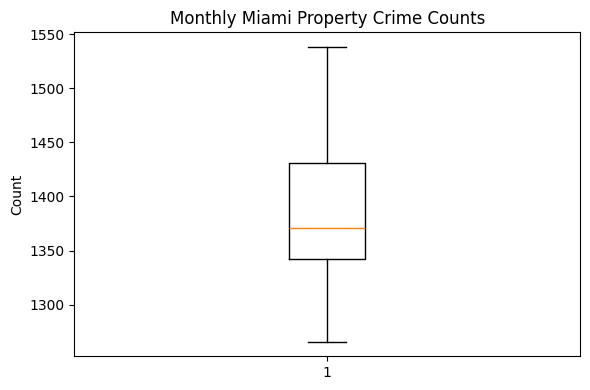

In [5]:
plt.figure(figsize=(6, 4))
plt.boxplot(comparison_df["Property_Crimes"])
plt.title("Monthly Miami Property Crime Counts")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

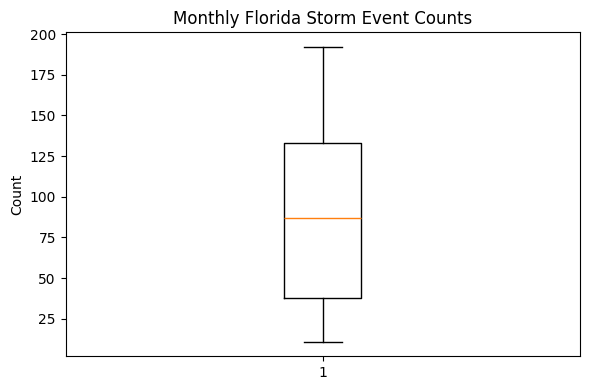

In [6]:
plt.figure(figsize=(6, 4))
plt.boxplot(comparison_df["Storm_Events"])
plt.title("Monthly Florida Storm Event Counts")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
def iqr_outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((series < lower) | (series > upper)).sum()

    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Fence": lower,
        "Upper Fence": upper,
        "Outlier Count": int(outlier_count),
    })

pd.DataFrame({
    "Property Crimes": iqr_outlier_summary(comparison_df["Property_Crimes"]),
    "Storm Events": iqr_outlier_summary(comparison_df["Storm_Events"]),
}).T.round(2)

,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
Property Crimes,1342.50,1431.25,88.75,1209.38,1564.38,0.0
Storm Events,37.75,133.00,95.25,-105.12,275.88,0.0


Using the standard 1.5 × IQR rule, neither monthly series contains an identified outlier. The storm-event series nevertheless shows substantially greater month-to-month variability than the property-crime series.

## 6. Monthly Patterns

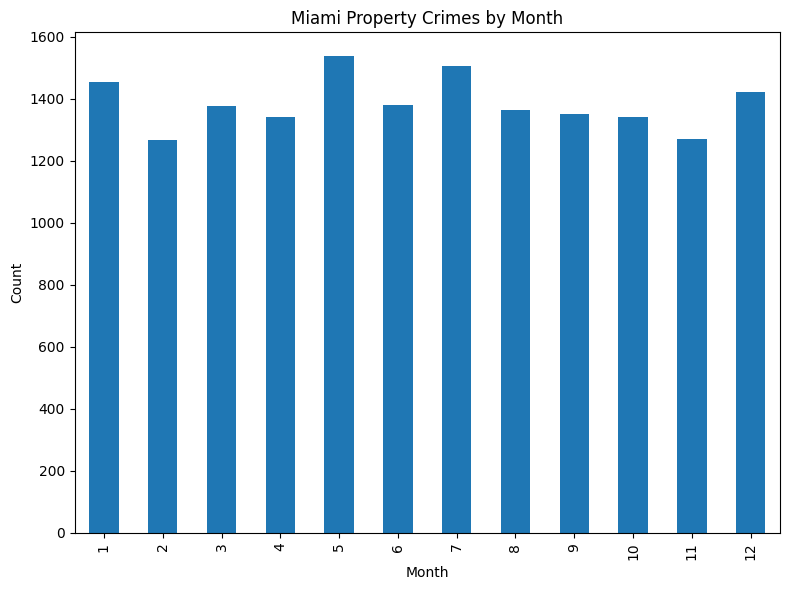

In [8]:
plt.figure(figsize=(8, 6))
comparison_df["Property_Crimes"].plot(kind="bar")
plt.title("Miami Property Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

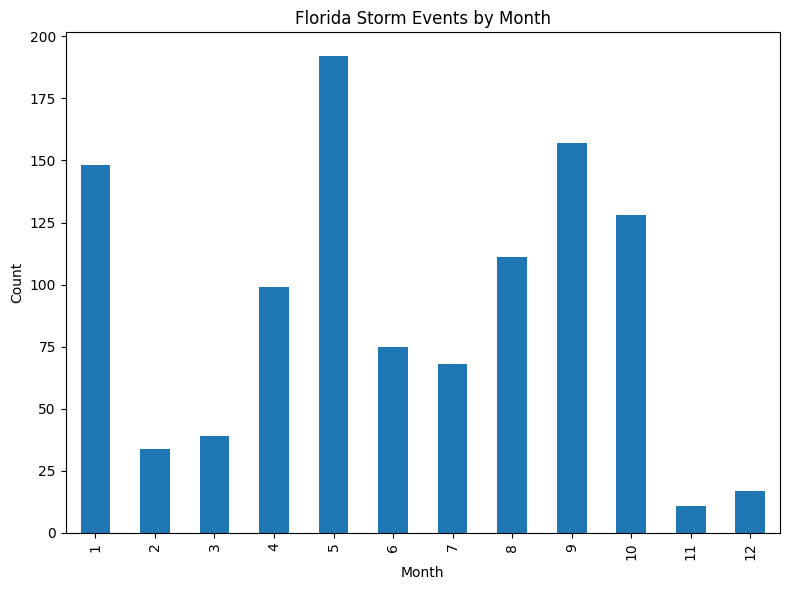

In [9]:
plt.figure(figsize=(8, 6))
comparison_df["Storm_Events"].plot(kind="bar")
plt.title("Florida Storm Events by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Property crime remained comparatively stable across the year, while storm-event frequency fluctuated more sharply. The next view places both monthly series together to examine where peaks and declines appear to coincide.

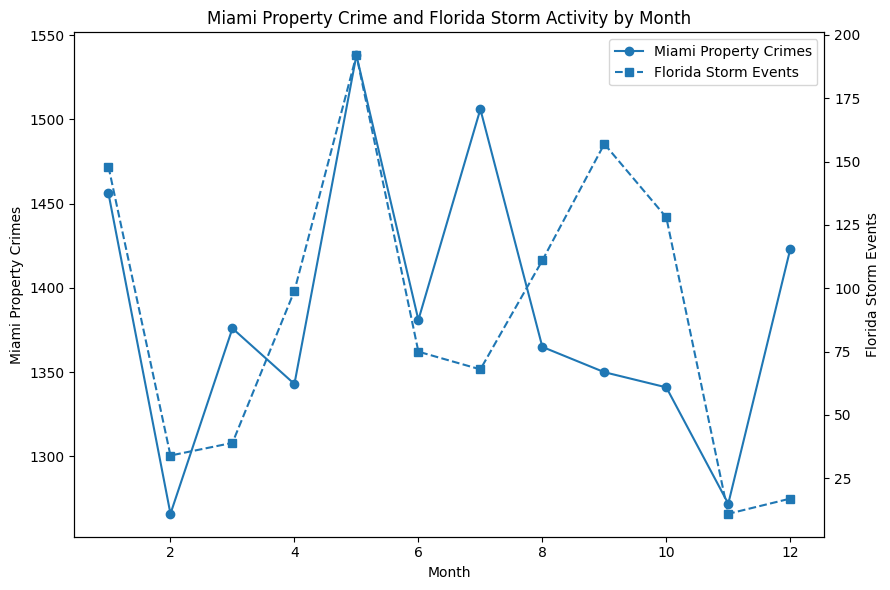

In [10]:
fig, ax1 = plt.subplots(figsize=(9, 6))

line1 = ax1.plot(
    comparison_df.index,
    comparison_df["Property_Crimes"],
    marker="o",
    label="Miami Property Crimes",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Miami Property Crimes")

ax2 = ax1.twinx()
line2 = ax2.plot(
    comparison_df.index,
    comparison_df["Storm_Events"],
    marker="s",
    linestyle="--",
    label="Florida Storm Events",
)
ax2.set_ylabel("Florida Storm Events")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Miami Property Crime and Florida Storm Activity by Month")
plt.tight_layout()
plt.show()

## 7. Pearson Correlation Analysis

The monthly comparison suggests some periods in which higher storm activity coincides with higher property crime, but the pattern is not consistent.

Pearson correlation was used to quantify the linear relationship.

- **H₀:** Monthly Florida storm-event frequency and Miami property-crime frequency have no linear correlation.
- **Hₐ:** A linear correlation exists between the two monthly series.
- **Significance level:** α = 0.05

In [11]:
corr, p_value = pearsonr(
    comparison_df["Storm_Events"],
    comparison_df["Property_Crimes"],
)

results = pd.DataFrame({
    "Statistic": ["Pearson r", "p-value", "Significance level"],
    "Value": [corr, p_value, ALPHA],
})

results.round(3)

,Statistic,Value
0,Pearson r,0.472
1,p-value,0.121
2,Significance level,0.050


### Correlation Scatterplot

Each point represents one month. The dashed line shows the fitted linear trend.

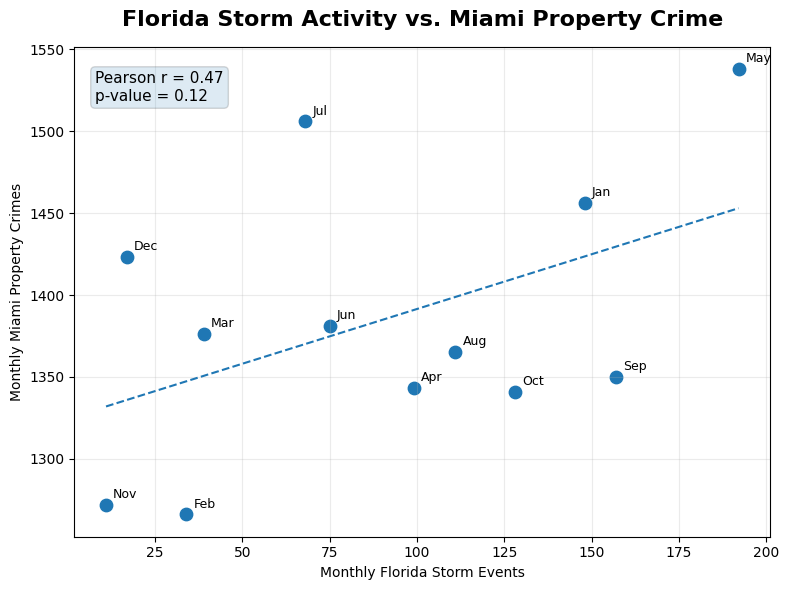

In [12]:
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Storm_Events"],
    comparison_df["Property_Crimes"],
    s=80,
)

slope, intercept = np.polyfit(
    comparison_df["Storm_Events"],
    comparison_df["Property_Crimes"],
    1,
)

x_line = np.linspace(
    comparison_df["Storm_Events"].min(),
    comparison_df["Storm_Events"].max(),
    100,
)

plt.plot(
    x_line,
    slope * x_line + intercept,
    linestyle="--",
)

for month, row in comparison_df.iterrows():
    plt.annotate(
        month_names[int(month)],
        (row["Storm_Events"], row["Property_Crimes"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

plt.title(
    "Florida Storm Activity vs. Miami Property Crime",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Monthly Florida Storm Events")
plt.ylabel("Monthly Miami Property Crimes")

plt.text(
    0.03,
    0.95,
    f"Pearson r = {corr:.2f}\np-value = {p_value:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(boxstyle="round", alpha=0.15),
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Interpretation

The Pearson correlation is approximately **r = 0.47**, indicating a moderate positive linear relationship between monthly Florida storm-event frequency and Miami property-crime frequency.

However, the associated **p-value is approximately 0.12**, which is greater than the 0.05 significance level. The null hypothesis is therefore **not rejected**.

The 2024 data do not provide sufficient statistical evidence to conclude that monthly storm-event frequency is significantly associated with increased property crime. The result should not be interpreted as evidence that storms cause changes in crime.

## 9. Limitations and Future Analysis

### Limitations

- Only one calendar year of data was available.
- Miami crime activity was compared with statewide Florida storm-event frequency.
- Defining property crime required analyst judgment because no predefined property-crime flag was available.
- Pearson correlation evaluates linear association and does not establish causation.
- More precise geographic matching would require additional location processing or GIS methods.

### Future Analysis

A stronger follow-up study could:

- incorporate multiple years of crime and storm data;
- isolate hurricanes, tropical storms, and other severe-weather categories;
- match storm events and crime locations using geographic or GIS-based methods;
- compare crime activity before, during, and after major storm events;
- evaluate seasonality and additional predictors in a multivariable or predictive model.

## Portfolio Note

This notebook is a cleaned portfolio version of the original course analysis. Classroom instructions, hard-coded database credentials, redundant inspection cells, and unused exploratory code were removed or consolidated while preserving the original analytical workflow and reported results.